In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns=['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope',
         'ca','thal','target']
df=pd.read_csv(url,names=columns,na_values='?')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [2]:
df.shape

(303, 14)

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
print("original target value count:")
print(df['target'].value_counts().sort_index())


original target value count:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [5]:
print("data convert to binary for classification")
df['target']=(df['target']>0).astype(int)
print("After Converting (0=No Disease ,1=Disease)")
print(df['target'].value_counts())

data convert to binary for classification
After Converting (0=No Disease ,1=Disease)
target
0    164
1    139
Name: count, dtype: int64


In [6]:
total=len(df)
disease=df['target'].sum()
no_disease=total-disease
print(f"No Disease:{no_disease} ({no_disease/total*100}%)")
print(f"Disease:{disease} ({disease/total*100}%)")


No Disease:164 (54.12541254125413%)
Disease:139 (45.87458745874587%)


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
df.dropna(inplace=True)
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [10]:
import seaborn as sns
corr_matrix=df.corr()
corr_matrix['target'].drop('target').sort_values(ascending=False)


,target
thal,0.526640
ca,0.463189
oldpeak,0.424052
exang,0.421355
cp,0.408945
slope,0.333049
sex,0.278467
age,0.227075
restecg,0.166343
trestbps,0.153490


array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='trestbps', ylabel='age'>,
        <Axes: xlabel='chol', ylabel='age'>,
        <Axes: xlabel='thalach', ylabel='age'>,
        <Axes: xlabel='oldpeak', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='trestbps'>,
        <Axes: xlabel='trestbps', ylabel='trestbps'>,
        <Axes: xlabel='chol', ylabel='trestbps'>,
        <Axes: xlabel='thalach', ylabel='trestbps'>,
        <Axes: xlabel='oldpeak', ylabel='trestbps'>],
       [<Axes: xlabel='age', ylabel='chol'>,
        <Axes: xlabel='trestbps', ylabel='chol'>,
        <Axes: xlabel='chol', ylabel='chol'>,
        <Axes: xlabel='thalach', ylabel='chol'>,
        <Axes: xlabel='oldpeak', ylabel='chol'>],
       [<Axes: xlabel='age', ylabel='thalach'>,
        <Axes: xlabel='trestbps', ylabel='thalach'>,
        <Axes: xlabel='chol', ylabel='thalach'>,
        <Axes: xlabel='thalach', ylabel='thalach'>,
        <Axes: xlabel='oldpeak', ylabel='thalach'>],
       [<A

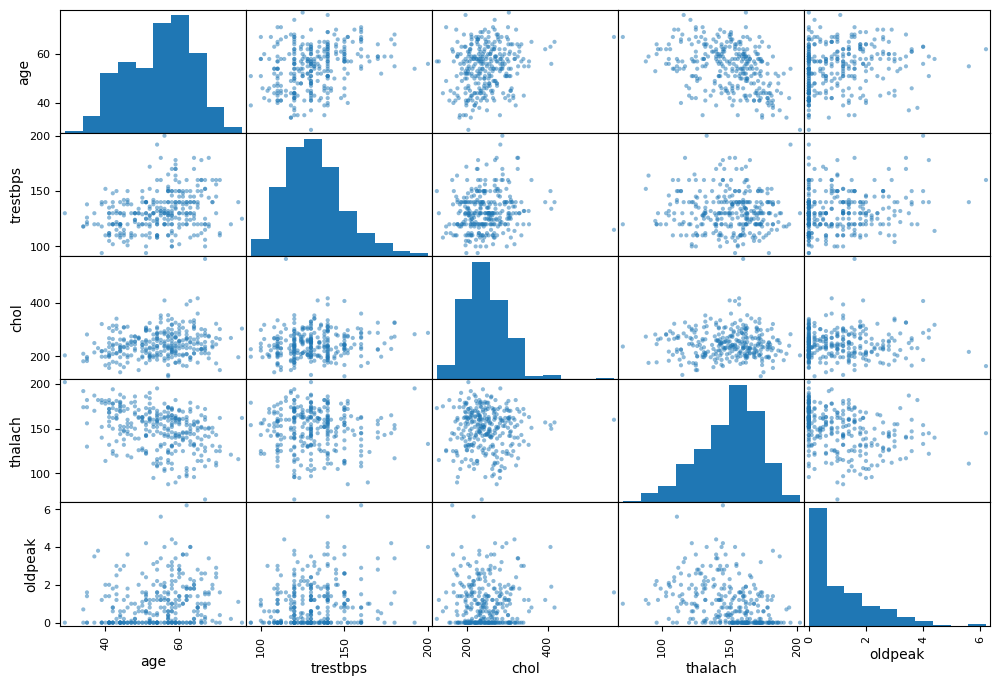

In [11]:
from pandas.plotting import scatter_matrix
continous=['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scatter_matrix(df[continous],figsize=(12,8))

/tmp/ipykernel_18852/740799217.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette="RdYlBu")
/tmp/ipykernel_18852/740799217.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette="RdYlBu")
/tmp/ipykernel_18852/740799217.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette="RdYlBu")
/tmp/ipykernel_18852/740799217.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

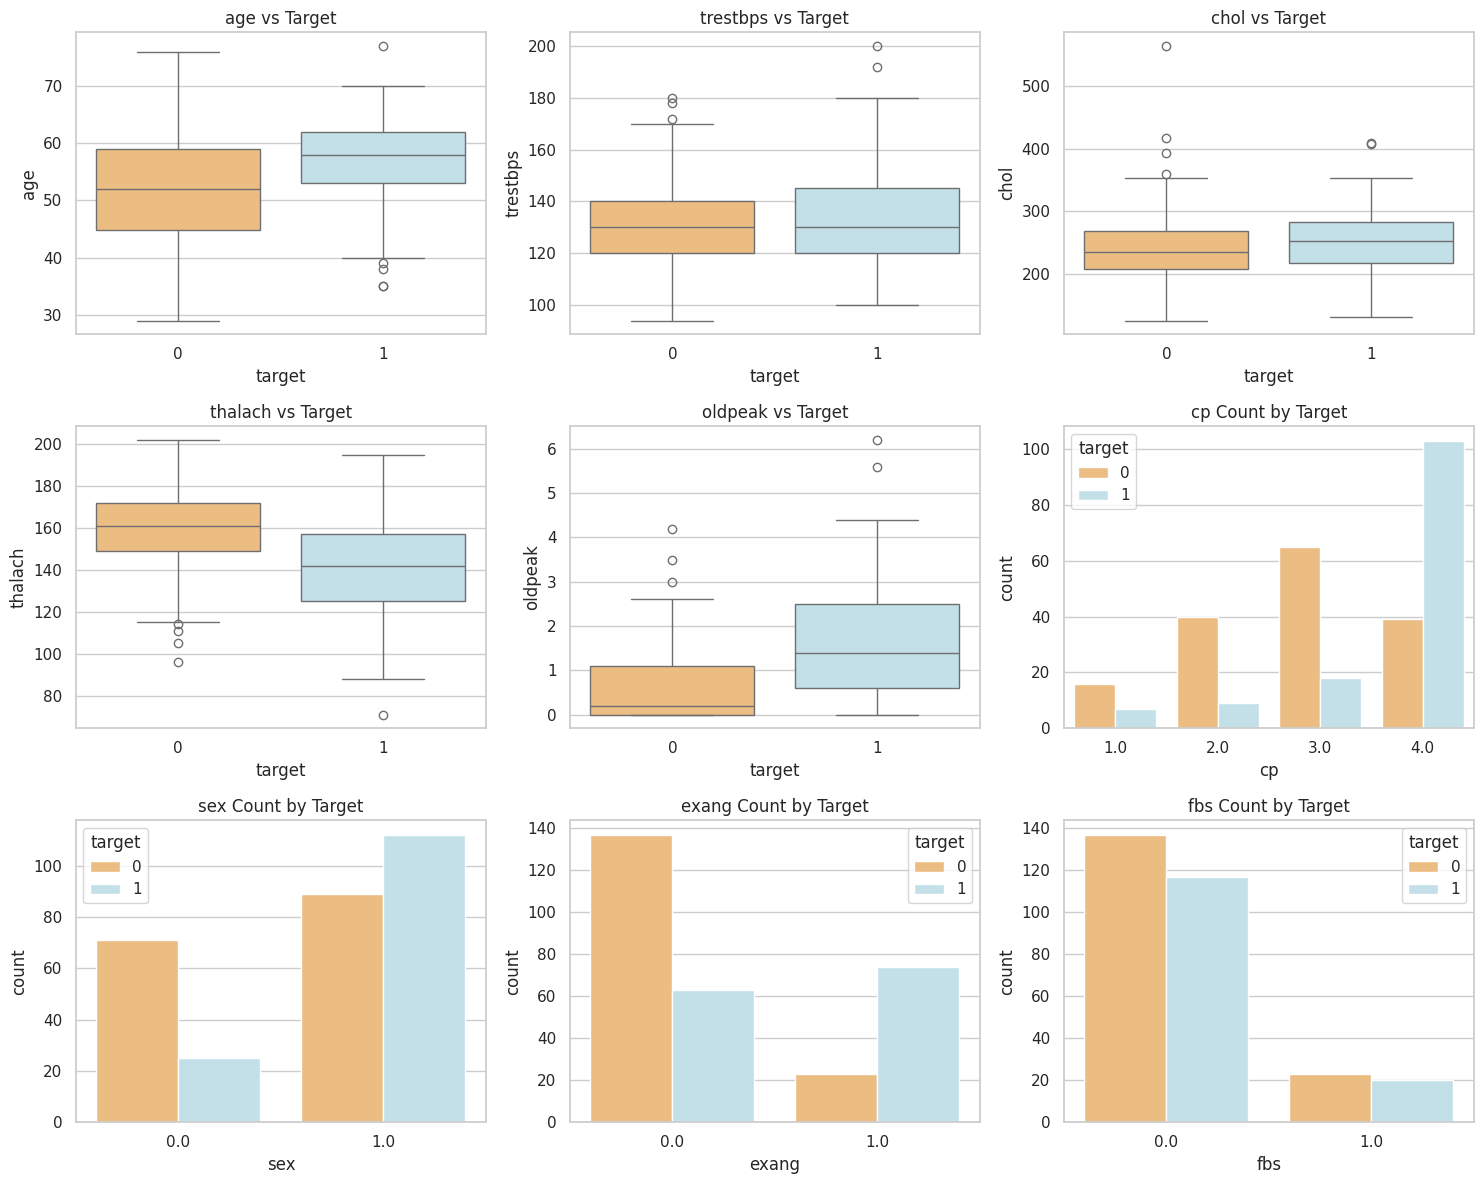

In [12]:


# Set the style and the grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# 1. Plot Continuous Features (Age, BP, Cholesterol, etc.)
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for i, col in enumerate(continuous):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette="RdYlBu")
    axes[i].set_title(f"{col} vs Target")

# 2. Plot Categorical Features (Chest Pain, Sex, etc.)
categorical = ['cp', 'sex', 'exang', 'fbs']
for i, col in enumerate(categorical):
    # We add len(continuous) to the index to start where we left off
    ax_idx = len(continuous) + i
    sns.countplot(data=df, x=col, hue='target', ax=axes[ax_idx], palette="RdYlBu")
    axes[ax_idx].set_title(f"{col} Count by Target")

plt.tight_layout()
plt.show()


In [13]:
categorical=['cp','restecg','slope','thal']
numerical=['age','sex','trestbps','chol','fbs','thalach','exang','oldpeak','ca']


In [14]:
#one hot enncoding keep the value true everything else false
df_encoded = pd.get_dummies(df, columns=categorical, drop_first=False)
print("Shape AFTER one-hot encoding:", df_encoded.shape)
print("New columns created:", [c for c in df_encoded.columns if '_' in c][:10])


Shape AFTER one-hot encoding: (297, 23)
New columns created: ['cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0']


In [15]:
#feature scaling
X = df_encoded.drop('target', axis=1).values
y = df_encoded['target'].values
features = df_encoded.drop('target', axis=1).columns.tolist()
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (297, 22)
Target (y) shape: (297,)


In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

train_disease_pct=(y_train.sum()/len(y_train))*100
test_disease_pct=(y_test.sum())/len(y_test)*100
print(train_disease_pct,test_disease_pct)

45.9915611814346 46.666666666666664


In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("Checking Scaling")
scaled_df_sample = pd.DataFrame(X_train_scaled, columns=features)
scaled_df_sample[['age', 'chol']].describe()

Checking Scaling


,age,chol
count,2.370000e+02,2.370000e+02
mean,-2.398456e-16,-2.501515e-16
std,1.002116e+00,1.002116e+00
min,-2.304616e+00,-2.326280e+00
25%,-7.513526e-01,-7.051694e-01
50%,1.362266e-01,-1.208157e-01
75%,8.019109e-01,5.200883e-01
max,2.466122e+00,5.930072e+00


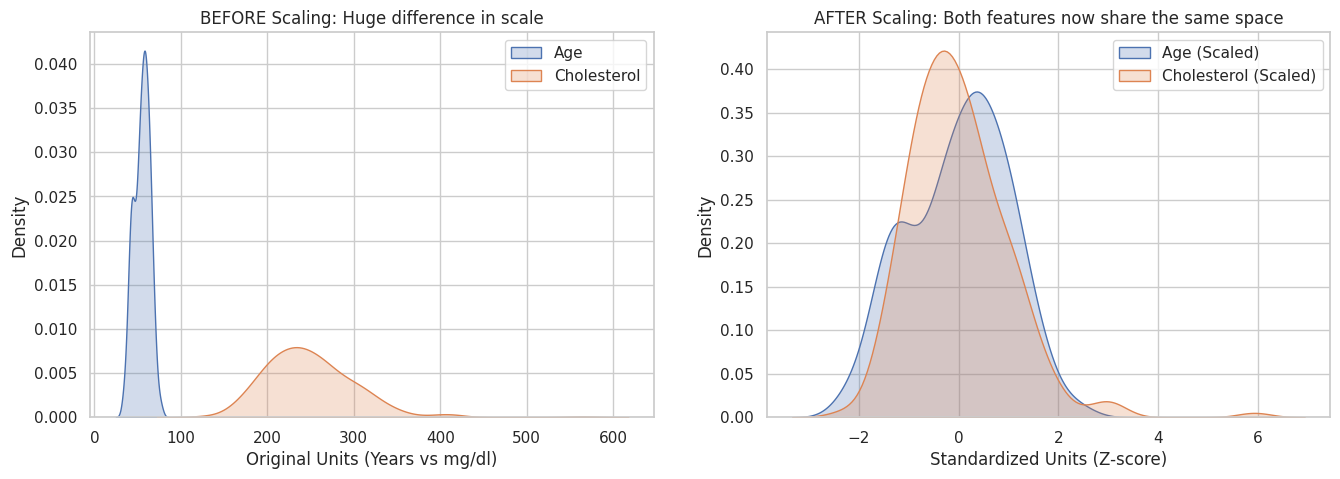

In [18]:

# We pick two features with very different scales to compare
cols = ['age', 'chol']
age_idx, chol_idx = features.index('age'),features.index('chol')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. BEFORE: Plotting the raw distributions
sns.kdeplot(X_train[:, age_idx], ax=ax1, label='Age', fill=True)
sns.kdeplot(X_train[:, chol_idx], ax=ax1, label='Cholesterol', fill=True)
ax1.set_title("BEFORE Scaling: Huge difference in scale")
ax1.set_xlabel("Original Units (Years vs mg/dl)")
ax1.legend()

# 2. AFTER: Plotting the scaled distributions
sns.kdeplot(X_train_scaled[:, age_idx], ax=ax2, label='Age (Scaled)', fill=True)
sns.kdeplot(X_train_scaled[:, chol_idx], ax=ax2, label='Cholesterol (Scaled)', fill=True)
ax2.set_title("AFTER Scaling: Both features now share the same space")
ax2.set_xlabel("Standardized Units (Z-score)")
ax2.legend()

plt.show()


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout, Input
n_features=X_train_scaled.shape[1]
print("Number of input features:",n_features)
model=Sequential([
    Input(shape=(n_features,)), #tell kera what shape to expect
    Dense(64,activation='relu'),#hidden layer 1:64 neurons
    Dropout(0.3),#switching 30% of neurons randomly
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')



])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
model.summary()


Number of input features: 22


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
history=model.fit(
    X_train_scaled,y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1

)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6070 - loss: 0.6503 - val_accuracy: 0.6667 - val_loss: 0.6102
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7214 - loss: 0.5702 - val_accuracy: 0.7222 - val_loss: 0.5765
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7711 - loss: 0.5057 - val_accuracy: 0.6944 - val_loss: 0.5691
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8308 - loss: 0.4336 - val_accuracy: 0.6944 - val_loss: 0.5704
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8408 - loss: 0.3947 - val_accuracy: 0.6667 - val_loss: 0.5839
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8308 - loss: 0.3810 - val_accuracy: 0.6667 - val_loss: 0.6055
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8308 - loss: 0.3640 - val_accuracy: 0.6667 - val_loss: 0.6236
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8458 - loss: 0.3737 - val_accuracy: 0.6389 - 

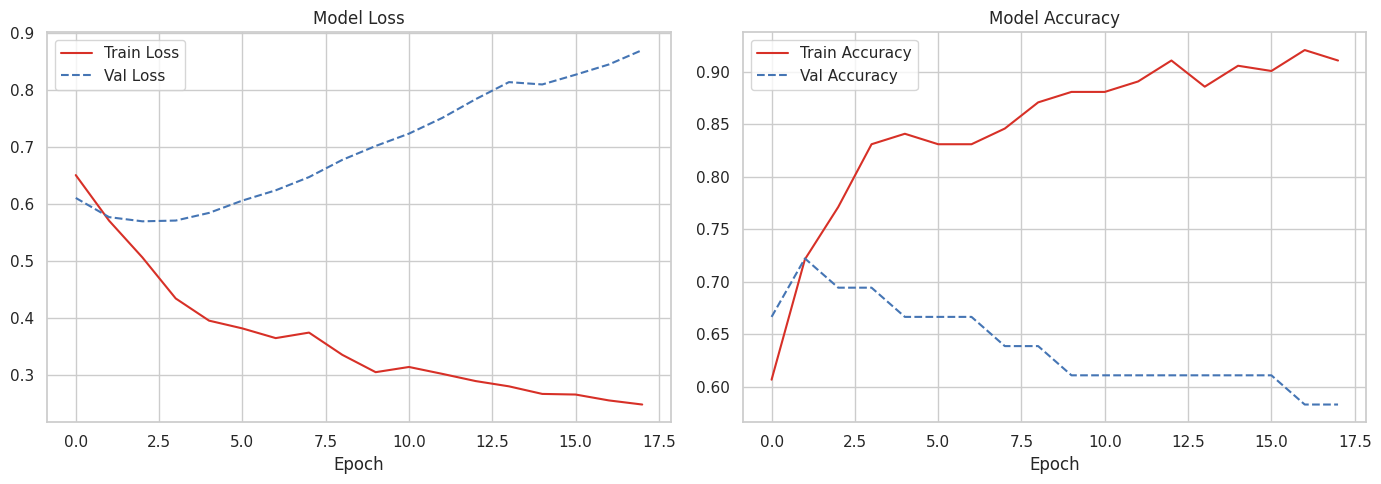

In [28]:
import matplotlib.pyplot as plt

metrics = ['loss', 'accuracy']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, m in enumerate(metrics):
    axes[i].plot(history.history[m], label=f'Train {m.capitalize()}', color='#d73027')
    axes[i].plot(history.history[f'val_{m}'], label=f'Val {m.capitalize()}', color='#4575b4', ls='--')
    axes[i].set_title(f"Model {m.capitalize()}")
    axes[i].set_xlabel('Epoch')
    axes[i].legend()

plt.tight_layout()
plt.show()


In [35]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
print("CLASSIFICATION REPORT")

print(classification_report(y_test, y_pred,
                             target_names=['No Disease','Disease']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.81      0.94      0.87        32
     Disease       0.91      0.75      0.82        28

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.86      0.85      0.85        60



In [37]:
confusion_matrix(y_test,y_pred)


array([[30,  2],
       [ 7, 21]])

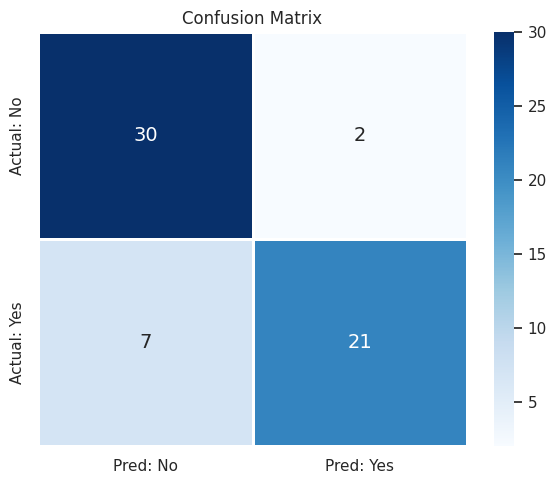

In [38]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No','Pred: Yes'],
            yticklabels=['Actual: No','Actual: Yes'],
            linewidths=2, annot_kws={"size":14})
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [46]:
def heartguard_predict(patient_data: dict) -> dict:
    """
    Input:  dictionary of patient values
    Output: risk prediction with probability

    This is the 'agent' — it takes raw input, applies the full
    preprocessing pipeline, and returns a human-readable result.
    """

    input_df = pd.DataFrame([patient_data])

    input_encoded = pd.get_dummies(input_df,
                                   columns=['cp','restecg','slope','thal'],
                                   drop_first=False)

    input_encoded = input_encoded.reindex(columns=features, fill_value=0)

    input_scaled = scaler.transform(input_encoded.values)

    probability = float(model.predict(input_scaled, verbose=0)[0][0])
    prediction  = int(probability >= 0.5)

    return {
        'prediction':  prediction,
        'probability': round(probability, 4),
        'risk':        "HIGH RISK" if prediction == 1 else "LOW RISK"
    }

print("="*45)
print("HEARTGUARD AGENT — PATIENT ASSESSMENT")
print("="*45)

at_risk = {
    'age': 67, 'sex': 1, 'cp': 4, 'trestbps': 160,
    'chol': 286, 'fbs': 0, 'restecg': 2, 'thalach': 108,
    'exang': 1, 'oldpeak': 1.5, 'slope': 2, 'ca': 3, 'thal': 3
}
result_risk = heartguard_predict(at_risk)
print(f"Patient: High Risk Profile")
print(f"Probability of disease : {result_risk['probability']:.1%}")
print(f"Risk Level             : {result_risk['risk']}")

print("="*45)

healthy = {
    'age': 35, 'sex': 0, 'cp': 0, 'trestbps': 110,
    'chol': 180, 'fbs': 0, 'restecg': 0, 'thalach': 175,
    'exang': 0, 'oldpeak': 0.0, 'slope': 2, 'ca': 0, 'thal': 3
}
result_healthy = heartguard_predict(healthy)
print(f"Patient: Healthy Profile")
print(f"Probability of disease : {result_healthy['probability']:.1%}")
print(f"Risk Level             : {result_healthy['risk']}")
print("="*45)

HEARTGUARD AGENT — PATIENT ASSESSMENT
Patient: High Risk Profile
Probability of disease : 50.1%
Risk Level             : HIGH RISK
Patient: Healthy Profile
Probability of disease : 19.4%
Risk Level             : LOW RISK
